# Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Basic Info

In [11]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# Display basic information
print("--- Data Information ---")
df.info()

# Summary statistics
print("\n--- Summary Statistics ---")
display(df.describe())

# fisrt five 
print("\n ---- head of data set ---")
df.head()

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Summary Statistics ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



 ---- head of data set ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Checking for NULL Values

In [12]:
# Checking for missing values in every column
print("--- NULL Values Count ---")
print(df.isnull().sum())

--- NULL Values Count ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# Data Visualization

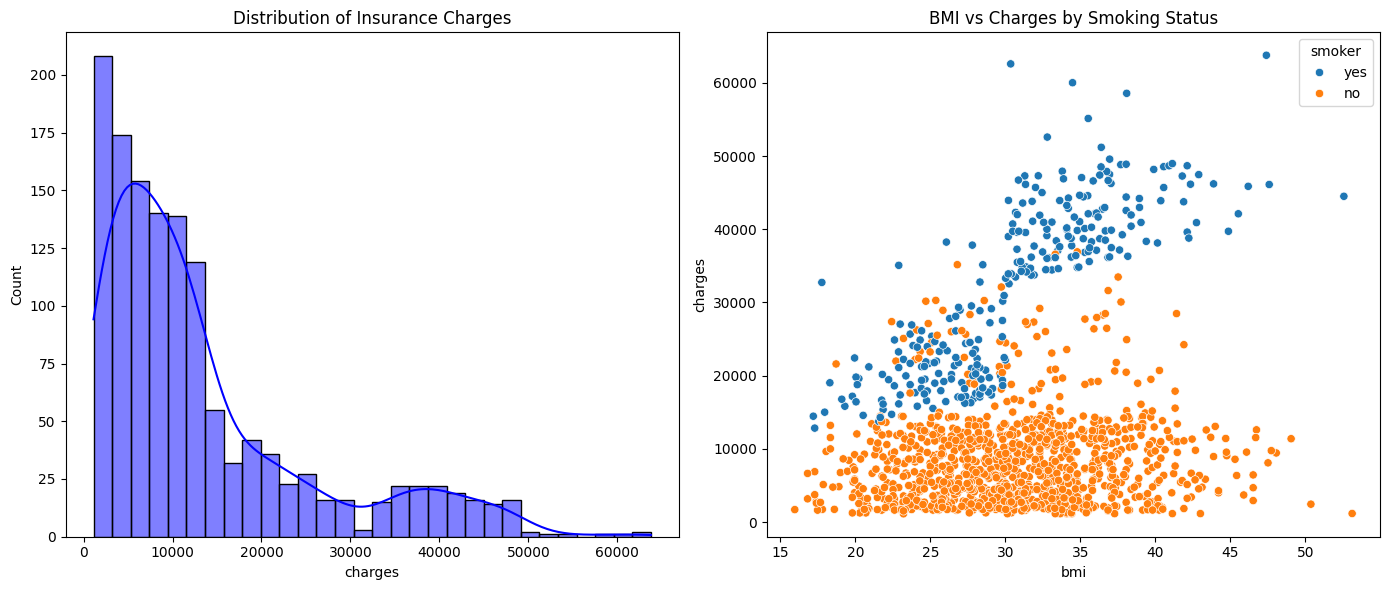

In [13]:
plt.figure(figsize=(14, 6))

# Plot 1: Distribution of Charges
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')

# Plot 2: BMI vs Charges (Colored by Smoker)
plt.subplot(1, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges by Smoking Status')

plt.tight_layout()
plt.show()

# Data Preprocessing and Splitting

In [14]:
# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Define column types
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']

# Preprocessing: Scale numbers and One-Hot Encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training and Testing Models

In [15]:
# 1. Linear Regression Pipeline
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)

# 2. SVR Pipeline
# We scale 'y' because SVR is distance-based
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

svr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=100, epsilon=0.1))
])
svr_model.fit(X_train, y_train_scaled)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Evaluation

In [18]:
# Assuming 1 USD = 83 INR
conversion_rate = 93.1325

# Linear Regression Predictions
y_pred_lr = lr_model.predict(X_test)

# SVR Predictions (and reversing the scale)
y_pred_svr_scaled = svr_model.predict(X_test)
y_pred_svr = y_scaler.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).flatten()

# Evaluation Function updated for Indian Currency
def evaluate_in_inr(y_true, y_pred, name):
    # Convert dollar values to INR
    mae_inr = mean_absolute_error(y_true, y_pred) * conversion_rate
    rmse_inr = np.sqrt(mean_squared_error(y_true, y_pred)) * conversion_rate
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {name} (Results in INR) ---")
    print(f"MAE:  ₹{mae_inr:,.2f}")
    print(f"RMSE: ₹{rmse_inr:,.2f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate_in_inr(y_test, y_pred_lr, "Linear Regression")
evaluate_in_inr(y_test, y_pred_svr, "SVR (RBF Kernel)")

--- Linear Regression (Results in INR) ---
MAE:  ₹389,405.09
RMSE: ₹539,822.48
R2 Score: 0.7836

--- SVR (RBF Kernel) (Results in INR) ---
MAE:  ₹275,979.01
RMSE: ₹492,703.57
R2 Score: 0.8197



# Exporting Models with Pickle

In [19]:
import pickle

# 1. Save the Linear Regression model
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# 2. Save the SVR model
with open('svr_model.pkl', 'wb') as f:
    pickle.dump(svr_model, f)

# 3. Save the Target Scaler (CRITICAL for SVR)
with open('y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)

print("All files saved as .pkl!")

All files saved as .pkl!
